# 05 · Monitoring & Learning Agent (feedback loop)

The Monitor scores each pricing decision (revenue, off-peak uplift, wait-time reduction, pricing efficiency) and tunes the Tariff Agent's surge/discount sensitivity over episodes. The loop **discovers** that blanket off-peak discounts are revenue-negative under inelastic demand, converging on a surge-led policy.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from src.run_pipeline import main
main()

2026-06-07 01:43:35,218 INFO data validated: {'rows': 279193, 'rows_by_source': {'acn': 101353, 'urbanev': 177840}, 'checks_passed': 6}


2026-06-07 01:43:36,713 INFO demand models saved to /Users/yashbansal/Desktop/socbiz openproj/models


2026-06-07 01:43:39,285 INFO PIPELINE COMPLETE | demand R2 (UrbanEV)=0.948


2026-06-07 01:43:39,286 INFO elasticity by state: {'low': -0.514, 'mid': -0.125, 'high': -0.001, 'vhigh': -0.001}


2026-06-07 01:43:39,286 INFO revenue gain % [neutral / full x1.20]: 2.76 / 20.49


2026-06-07 01:43:39,287 INFO off-peak uplift % [neutral]: 15.29 | composite 6.52 -> 20.23


2026-06-07 01:43:39,287 INFO outputs -> /Users/yashbansal/Desktop/socbiz openproj/outputs | models -> /Users/yashbansal/Desktop/socbiz openproj/models


### Learning curve — composite objective rises as the agent learns

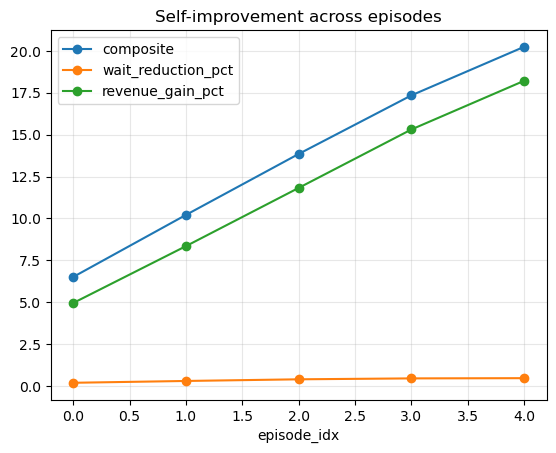

,revenue_gain_pct,offpeak_uplift_pct,wait_reduction_pct,customer_response_pct,pricing_efficiency,composite,surge_sensitivity,discount_sensitivity,episode_idx
0,4.96,4.90,0.21,0.82,1.04,6.52,0.5,1.2,0
1,8.35,5.78,0.31,0.90,1.07,10.21,0.8,1.4,1
2,11.82,6.19,0.41,0.89,1.11,13.85,1.1,1.5,2
3,15.31,6.15,0.47,0.79,1.14,17.34,1.4,1.5,3
4,18.21,6.11,0.48,0.69,1.17,20.23,1.7,1.5,4


In [2]:
import pandas as pd, matplotlib.pyplot as plt
log = pd.read_csv('../outputs/monitor_episodes.csv')
ax = log.plot(x='episode_idx', y=['composite','wait_reduction_pct','revenue_gain_pct'], marker='o')
ax.set_title('Self-improvement across episodes'); ax.grid(alpha=.3); plt.show()
log.round(2)

### Consolidated headline KPIs

In [3]:
pd.read_csv('../outputs/final_kpis.csv').T

,0
elasticity_overall,-0.288901
eps_low,-0.514330
eps_mid,-0.124704
eps_high,-0.001000
eps_vhigh,-0.001000
demand_r2_urbanev,0.947781
demand_rmse_urbanev,0.039977
revenue_gain_neutral_pct,2.756690
revenue_gain_full_pct,20.486210
avg_price_multiplier_full,1.202412
